In [1]:
"""
Wildlife Piece Detection Training Notebook

This notebook trains a YOLOv8 model to detect wildlife pieces in images.
The pipeline includes dataset preparation, train/val splitting, model training,
validation, and model export.

Author: NCSU - Fall 2025 Board Game Project
"""

# ============================================================================
# IMPORTS
# ============================================================================

import os
import shutil
import random
from pathlib import Path
from ultralytics import YOLO  # YOLOv8 implementation
import yaml  # For creating configuration files
import torch  # PyTorch deep learning framework
from torch.serialization import add_safe_globals
from ultralytics.nn.tasks import DetectionModel
from dotenv import load_dotenv


In [2]:
# ============================================================================
# STEP 1: SETUP DATASET PATHS
# ============================================================================

# Define base directory containing the dataset
load_dotenv(Path("../../.env"))
base_dir = Path(os.environ["WILDLIFE_LABELS_DIR"])

images_dir = base_dir / "images"
labels_dir = base_dir / "labels"

# Output directory structure for YOLO training
output_dir = Path("./wildlife_piece_dataset")
train_images = output_dir / "train/images"
train_labels = output_dir / "train/labels"
val_images   = output_dir / "val/images"
val_labels   = output_dir / "val/labels"
test_images   = output_dir / "test/images"
test_labels   = output_dir / "test/labels"

# This will create the train/val directory structure
for d in [train_images, train_labels, val_images, val_labels, test_images, test_labels]:
    d.mkdir(parents=True, exist_ok=True)

In [3]:
# ============================================================================
# STEP 2: CROP IMAGES TO BOARD BOUNDING BOX
# ============================================================================

from ultralytics import YOLO

board_model = YOLO(os.environ["BOARD_DETECTOR_MODEL"])

cropped_images_dir = Path("./wildlife_piece_dataset/cropped_images")
cropped_labels_dir = Path("./wildlife_piece_dataset/cropped_labels")
cropped_images_dir.mkdir(parents=True, exist_ok=True)
cropped_labels_dir.mkdir(parents=True, exist_ok=True)

BOARD_CONF = 0.3  # lower threshold to not miss the board

all_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))

skipped = 0
for img_path in all_images:
    import cv2
    image = cv2.imread(str(img_path))
    if image is None:
        continue
    ih, iw = image.shape[:2]

    results = board_model(image, conf=BOARD_CONF, verbose=False)
    boxes = results[0].boxes

    if len(boxes) == 0:
        skipped += 1
        print(f"No board found in {img_path.name}, skipping.")
        continue

    # Take the highest confidence board detection
    best = boxes[boxes.conf.argmax()]
    x1, y1, x2, y2 = map(int, best.xyxy[0].tolist())
    x1, y1 = max(0, x1), max(0, y1)
    x2, y2 = min(iw, x2), min(ih, y2)

    crop = image[y1:y2, x1:x2]
    cw, ch = x2 - x1, y2 - y1

    # Read and remap labels to cropped coordinate space
    lbl_path = labels_dir / (img_path.stem + ".txt")
    if not lbl_path.exists():
        skipped += 1
        continue

    new_lines = []
    for line in lbl_path.read_text().splitlines():
        parts = line.strip().split()
        if len(parts) < 5:
            continue
        cls_id = int(parts[0])
        cx_n, cy_n, w_n, h_n = map(float, parts[1:5])

        # Convert normalized -> absolute (original image)
        cx_abs = cx_n * iw
        cy_abs = cy_n * ih
        w_abs  = w_n  * iw
        h_abs  = h_n  * ih

        # Shift to crop-local coords
        cx_crop = cx_abs - x1
        cy_crop = cy_abs - y1

        # Skip pieces whose center is outside the crop
        if not (0 <= cx_crop <= cw and 0 <= cy_crop <= ch):
            continue

        # Clamp box edges to crop boundaries
        bx1 = max(0, cx_crop - w_abs / 2)
        by1 = max(0, cy_crop - h_abs / 2)
        bx2 = min(cw, cx_crop + w_abs / 2)
        by2 = min(ch, cy_crop + h_abs / 2)
        new_w = bx2 - bx1
        new_h = by2 - by1

        # Renormalize to crop size
        new_lines.append(
            f"{cls_id} {(bx1+new_w/2)/cw:.6f} {(by1+new_h/2)/ch:.6f} {new_w/cw:.6f} {new_h/ch:.6f}"
        )

    if not new_lines:
        skipped += 1
        continue

    cv2.imwrite(str(cropped_images_dir / img_path.name), crop)
    (cropped_labels_dir / (img_path.stem + ".txt")).write_text("\n".join(new_lines))

print(f"Done. Cropped {len(list(cropped_images_dir.iterdir()))} images. Skipped {skipped}.")

# Point subsequent steps at the cropped dataset
images_dir = cropped_images_dir
labels_dir = cropped_labels_dir

Done. Cropped 52 images. Skipped 0.


In [4]:
# ============================================================================
# STEP 3: TRAIN/VALIDATION SPLIT
# ============================================================================

# Collect all image files from augmented dataset
all_images = list(images_dir.glob("*.jpg")) + list(images_dir.glob("*.png"))

# Set random seed for reproducible splits
random.seed(42)
random.shuffle(all_images)

# Split dataset: 80% training, 20% validation
train_val_split_idx = int(0.8 * len(all_images))
val_test_split_idx = int(0.9 * len(all_images))
train_files = all_images[:train_val_split_idx]
val_files   = all_images[train_val_split_idx:val_test_split_idx]
test_files  = all_images[val_test_split_idx:]

# Function to copy image and label files to train/val directories
def copy_files(file_list, dest_img_dir, dest_lbl_dir):
    """Copy images and their corresponding label files to destination"""
    for img_path in file_list:
        # Find corresponding label file
        lbl_path = labels_dir / (img_path.stem + ".txt")
        if lbl_path.exists():
            # Copy both image and label
            shutil.copy(img_path, dest_img_dir / img_path.name)
            shutil.copy(lbl_path, dest_lbl_dir / lbl_path.name)

# Copy files to their respective directories (uncomment to run)
copy_files(train_files, train_images, train_labels)
copy_files(val_files, val_images, val_labels)
copy_files(test_files, test_images, test_labels)

print(f"Copied {len(train_files)} train, {len(val_files)} val images and {len(test_files)} test images.")

Copied 41 train, 5 val images and 6 test images.


In [5]:
# ============================================================================
# STEP 4: CREATE YOLO CONFIGURATION FILE (data.yaml)
# ============================================================================

# YOLO requires a data.yaml file that specifies:
# - Paths to training and validation datasets
# - Number of classes (nc)
# - Class names

data_yaml = {
    "train": str(train_images.parent.resolve()),  # Path to train directory
    "val": str(val_images.parent.resolve()),      # Path to val directory
    "nc": 1,                                      # Number of classes (1 = board)
    "names": ["wildlife_piece"]                   # Class name(s)
}

# Write configuration to data.yaml file (uncomment to run)
with open(output_dir / "data.yaml", "w") as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print(f"data.yaml created at {output_dir / 'data.yaml'}")

data.yaml created at wildlife_piece_dataset/data.yaml


In [6]:
# ============================================================================
# STEP 5: CHECK FOR GPU AVAILABILITY
# ============================================================================

# Check if CUDA-compatible GPU is available
# Training on GPU is significantly faster than CPU
if torch.cuda.is_available():
    device = 0  # Use first GPU
    print(f"✅ Using GPU: {torch.cuda.get_device_name(0)}")
else:
    device = "cpu"  # Fall back to CPU
    print("⚠️ CUDA not available, falling back to CPU")
    print("Note: Training on CPU will be much slower. Consider using Google Colab with GPU.")

✅ Using GPU: NVIDIA GeForce RTX 3050 Laptop GPU


In [7]:
# ============================================================================
# STEP 6: TRAIN YOLO MODEL
# ============================================================================

# Load pre-trained YOLOv8 nano model
# yolov8n.pt is the smallest/fastest model
# For better accuracy, try: yolov8s.pt, yolov8m.pt, or yolov8l.pt
model = YOLO("yolov8s.pt")

# Train the model with specified parameters
results = model.train(
    data=str(output_dir / "data.yaml"),  # Path to data configuration file
    epochs=50,                           # Number of training epochs (increase for better results)
    imgsz=640,                           # Input image size (smaller = faster, larger = better accuracy)
    batch=4,                             # Batch size (reduce if out of memory)
    device=device,                       # Device: "cpu" or 0 for GPU
    workers=0,                           # Number of data loader workers (0 = disable multiprocessing)
    cache=True,                          # Cache images in RAM for faster training
    patience=10,                         # Early stopping: stop if no improvement for 5 epochs
    conf=0.25,                           # lower conf threshold during training eval
    iou=0.45,                            # tighter NMS for densely packed pieces
    name="wildlife-piece-detector",      # Name for this training run
    exist_ok=True,                       # Allow overwriting existing run
    verbose=True                         # Print training progress
)

# Training outputs:
# - Model checkpoints saved to: runs/detect/board-detector/weights/
# - Training logs and visualizations in: runs/detect/board-detector/
# - Best model: best.pt, Last model: last.pt

New https://pypi.org/project/ultralytics/8.4.39 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.209 🚀 Python-3.10.18 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.25, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=wildlife_piece_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.45, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=wildlife-piec

In [8]:
# ============================================================================
# STEP 7: VALIDATE MODEL PERFORMANCE
# ============================================================================

# Run validation on the validation set
# This calculates metrics like precision, recall, mAP (mean Average Precision)
metrics = model.val()

# Print validation metrics
print("\n=== Validation Metrics ===")
print(metrics)
print("\nKey metrics to check:")
print("- mAP50: Mean Average Precision at IoU threshold 0.5")
print("- mAP50-95: Mean Average Precision averaged over IoU 0.5-0.95")
print("- Precision: Accuracy of positive predictions")
print("- Recall: Fraction of actual boards detected")

Ultralytics 8.3.209 🚀 Python-3.10.18 torch-2.8.0+cu128 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 2.8±0.2 ms, read: 83.9±16.8 MB/s, size: 1320.0 KB)
val: Scanning /mnt/e/NCSU/Fall_2025/Board Game/piece_detection/src/wildlife_piece_detection/wildlife_piece_dataset/val/labels.cache... 5 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 5/5 4.1Kit/s 0.0s0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 1.6it/s 0.6s
                   all          5         39      0.872      0.697      0.821      0.365
Speed: 2.5ms preprocess, 201.1ms inference, 0.0ms loss, 13.3ms postprocess per image
Results saved to /mnt/e/NCSU/Fall_2025/Board Game/piece_detection/src/wildlife_piece_detection/runs/detect/val

=== Validation Metrics ===
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: ar

In [9]:
# ============================================================================
# STEP 8: TWO-STAGE INFERENCE (board → crop → pieces)
# ============================================================================

board_model = YOLO(os.environ["BOARD_DETECTOR_MODEL"])
loaded_model = YOLO("runs/detect/wildlife-piece-detector/weights/best.pt")

def detect_pieces_in_image(image_path, board_conf=0.3, piece_conf=0.2):
    import cv2
    image = cv2.imread(str(image_path))
    ih, iw = image.shape[:2]

    # Stage 1: detect board
    board_results = board_model(image, conf=board_conf, verbose=False)
    board_boxes = board_results[0].boxes

    if len(board_boxes) == 0:
        print("No board detected.")
        return []

    bx1, by1, bx2, by2 = map(int, board_boxes[board_boxes.conf.argmax()].xyxy[0].tolist())
    bx1, by1 = max(0, bx1), max(0, by1)
    bx2, by2 = min(iw, bx2), min(ih, by2)
    crop = image[by1:by2, bx1:bx2]

    # Stage 2: detect pieces in crop
    piece_results = loaded_model(crop, conf=piece_conf, verbose=False)
    detections = []
    for box in piece_results[0].boxes:
        px1, py1, px2, py2 = box.xyxy[0].tolist()
        # Map back to original image coords
        detections.append({
            "confidence": float(box.conf[0]),
            "box_original": [px1 + bx1, py1 + by1, px2 + bx1, py2 + by1],
            "box_crop": [px1, py1, px2, py2],
        })

    return detections

test_img = random.choice(test_files)
detections = detect_pieces_in_image(test_img)
print(f"Image: {test_img.name}")
print(f"Detected {len(detections)} wildlife pieces:")
for i, d in enumerate(detections):
    print(f"  Piece {i+1}: conf={d['confidence']:.3f}  box={[round(v) for v in d['box_original']]}")

Image: c9fd13b6-6-2050.jpg
Detected 12 wildlife pieces:
  Piece 1: conf=0.934  box=[1881, 1239, 2029, 1368]
  Piece 2: conf=0.876  box=[4331, 854, 4489, 960]
  Piece 3: conf=0.867  box=[4971, 436, 5090, 546]
  Piece 4: conf=0.769  box=[1873, 1231, 2062, 1377]
  Piece 5: conf=0.731  box=[4343, 147, 4489, 235]
  Piece 6: conf=0.668  box=[3987, 613, 4125, 719]
  Piece 7: conf=0.590  box=[4227, 482, 4349, 576]
  Piece 8: conf=0.586  box=[3472, 287, 3594, 384]
  Piece 9: conf=0.523  box=[4716, 429, 4867, 529]
  Piece 10: conf=0.420  box=[4195, 361, 4336, 443]
  Piece 11: conf=0.217  box=[3455, 275, 3610, 390]
  Piece 12: conf=0.213  box=[4486, 486, 4619, 581]


In [10]:
# ============================================================================
# STEP 8b: VISUALIZE INFERENCE RESULTS
# ============================================================================

import cv2

def visualize_detections(image_path, detections, board_box=None):
    image = cv2.imread(str(image_path))
    ih, iw = image.shape[:2]

    # Draw board bounding box in green
    if board_box:
        bx1, by1, bx2, by2 = board_box
        cv2.rectangle(image, (bx1, by1), (bx2, by2), (0, 255, 0), 3)
        cv2.putText(image, "Board", (bx1, by1 - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 255, 0), 2)

    # Draw each detected piece in red
    for i, d in enumerate(detections):
        x1, y1, x2, y2 = [int(v) for v in d["box_original"]]
        conf = d["confidence"]
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(image, f"{conf:.2f}", (x1, y1 - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 0, 255), 1)

    # Resize to fit screen
    max_w, max_h = 1280, 720
    h, w = image.shape[:2]
    scale = min(max_w / w, max_h / h, 1.0)
    if scale < 1.0:
        image = cv2.resize(image, (int(w * scale), int(h * scale)))

    cv2.imshow(Path(image_path).name, image)
    cv2.waitKey(0)
    cv2.destroyAllWindows()


# Update detect_pieces_in_image to also return the board box
def detect_pieces_in_image_v(image_path, board_conf=0.3, piece_conf=0.5):
    image = cv2.imread(str(image_path))
    ih, iw = image.shape[:2]

    board_results = board_model(image, conf=board_conf, verbose=False)
    board_boxes = board_results[0].boxes
    if len(board_boxes) == 0:
        print("No board detected.")
        return [], None

    bx1, by1, bx2, by2 = map(int, board_boxes[board_boxes.conf.argmax()].xyxy[0].tolist())
    bx1, by1 = max(0, bx1), max(0, by1)
    bx2, by2 = min(iw, bx2), min(ih, by2)
    crop = image[by1:by2, bx1:bx2]

    piece_results = loaded_model(crop, conf=piece_conf, verbose=False)
    detections = []
    for box in piece_results[0].boxes:
        px1, py1, px2, py2 = box.xyxy[0].tolist()
        detections.append({
            "confidence": float(box.conf[0]),
            "box_original": [px1 + bx1, py1 + by1, px2 + bx1, py2 + by1],
        })

    return detections, (bx1, by1, bx2, by2)


test_img = random.choice(test_files)
detections, board_box = detect_pieces_in_image_v(test_img)
print(f"Image: {test_img.name}  |  Board: {board_box}  |  Pieces: {len(detections)}")
visualize_detections(test_img, detections, board_box)

Image: 104f14bf-4-2040.jpg  |  Board: (0, 2, 2297, 3904)  |  Pieces: 4


In [11]:
# ============================================================================
# STEP 9: SAVE TRAINED MODEL
# ============================================================================

# Create directory for saving models
model_save_dir = Path("saved_models")
model_save_dir.mkdir(exist_ok=True)

# Copy the best weights from training to saved_models directory
# The best.pt file contains the model weights from the epoch with best validation performance
model_path = model_save_dir / "wildlife_piece_detector.pt"
shutil.copy("runs/detect/wildlife-piece-detector/weights/best.pt", model_path)
print(f"✅ Model saved to {model_path}")

✅ Model saved to saved_models/wildlife_piece_detector.pt


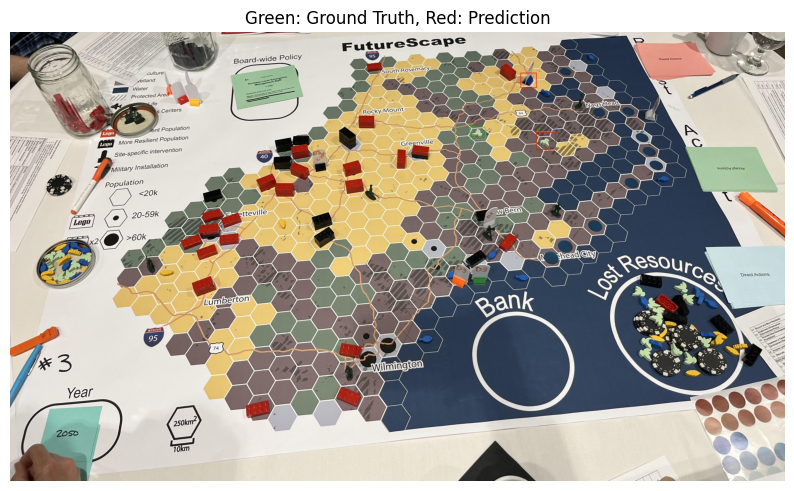

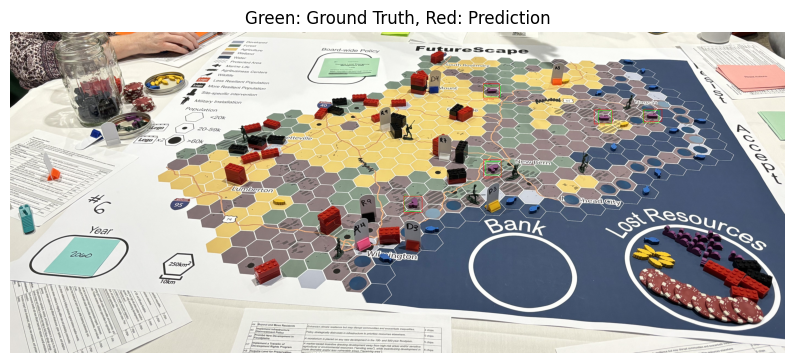

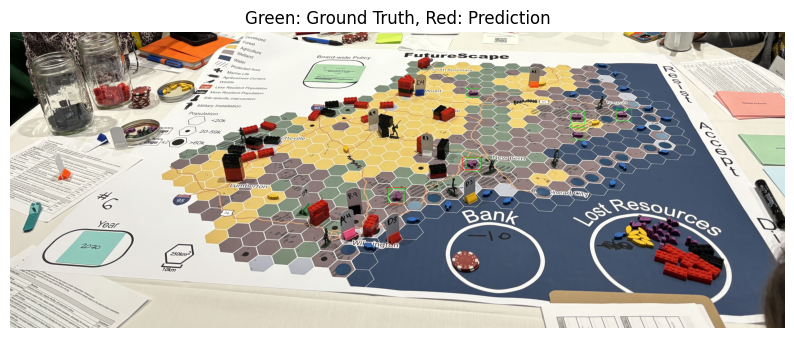

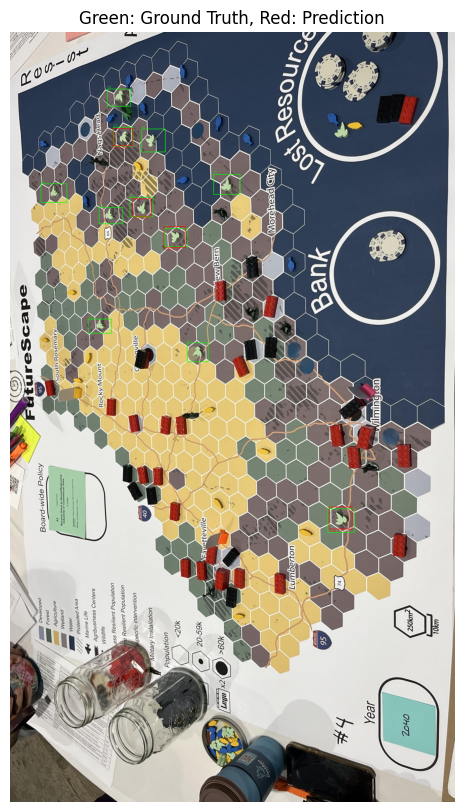

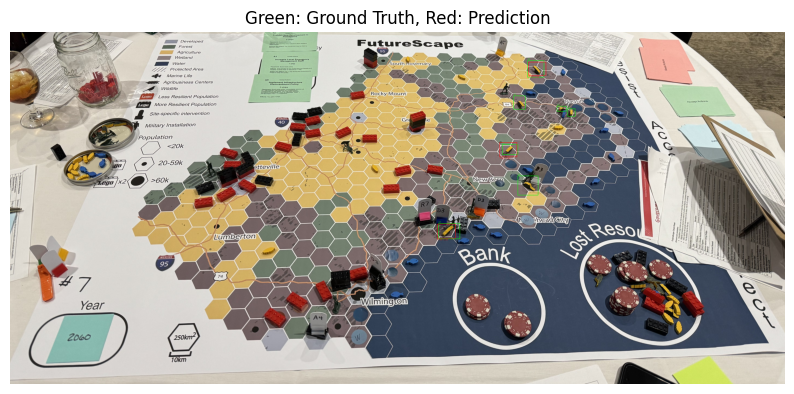

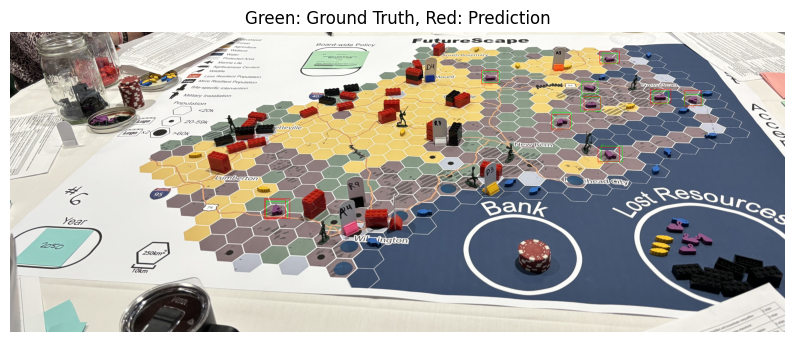

In [12]:
# ============================================================================ 
# STEP 10: VISUALIZE PREDICTIONS VS GROUND TRUTH
# ============================================================================ 

import cv2
import matplotlib.pyplot as plt
import random
try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

def load_ground_truth_boxes(label_path, img_shape):
    h, w = img_shape[:2]
    boxes = []
    if not label_path.exists():
        return boxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5: continue
            _, cx, cy, bw, bh = map(float, parts)
            # Convert YOLO format to box coordinates
            x1 = int((cx - bw/2) * w)
            y1 = int((cy - bh/2) * h)
            x2 = int((cx + bw/2) * w)
            y2 = int((cy + bh/2) * h)
            boxes.append([x1, y1, x2, y2])
    return boxes

def visualize_pred_vs_gt(image_path, detections, gt_boxes):
    image = cv2.imread(str(image_path))
    # Draw ground truth boxes in green
    for x1, y1, x2, y2 in gt_boxes:
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, 'GT', (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    # Draw predicted boxes in red
    for d in detections:
        x1, y1, x2, y2 = [int(v) for v in d['box_original']]
        conf = d['confidence']
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 0, 255), 2)
        cv2.putText(image, f'Pred {conf:.2f}', (x1, y2+15), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,0,255), 1)
    # Convert BGR to RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(10,10))
    plt.imshow(image)
    plt.axis('off')
    plt.title('Green: Ground Truth, Red: Prediction')
    plt.show()

# Pick a random test image

for i in range(len(test_files)):
    test_img = test_files[i]
    gt_label = labels_dir / (test_img.stem + '.txt')
    gt_boxes = load_ground_truth_boxes(gt_label, cv2.imread(str(test_img)).shape)
    detections, _ = detect_pieces_in_image_v(test_img)
    visualize_pred_vs_gt(test_img, detections, gt_boxes)